In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [3]:
image_cut = image[55:155, 0:1800]
image_error_cut = image_error[55:155, 0:1800]

Text(0.5, 0, 'wavelenght')

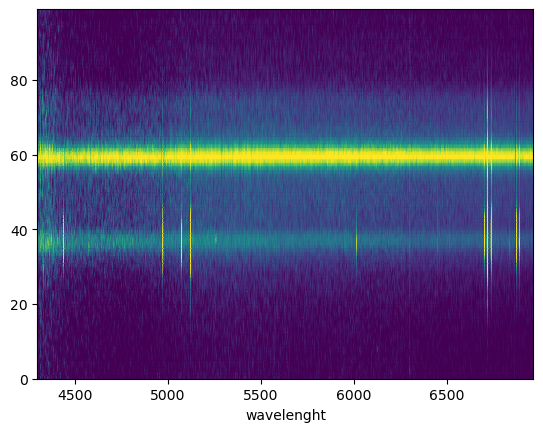

In [4]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

## Redshift or the lines in air

In [5]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

In [6]:
l_HA

6719.1994

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


Text(0.5, 0, 'wavelenght')

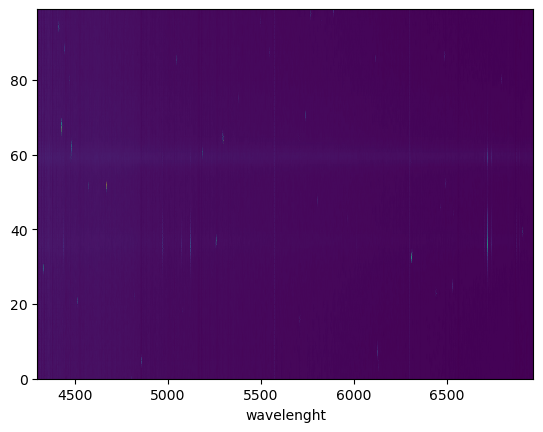

In [85]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[55:155, 0:1800]

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

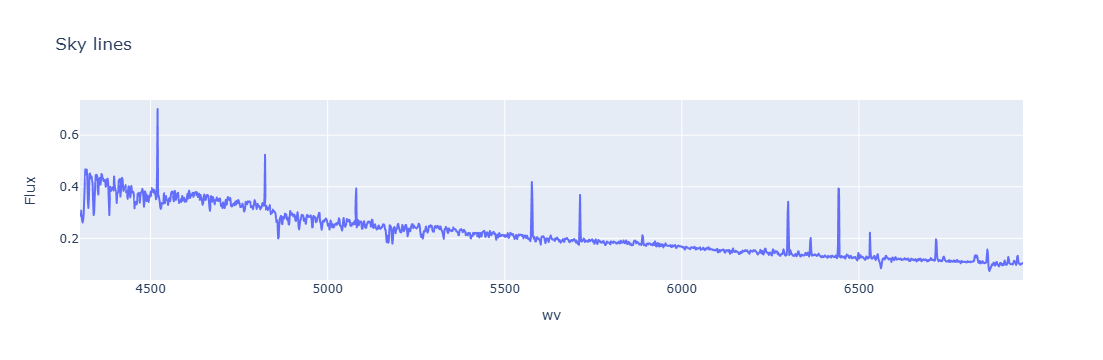

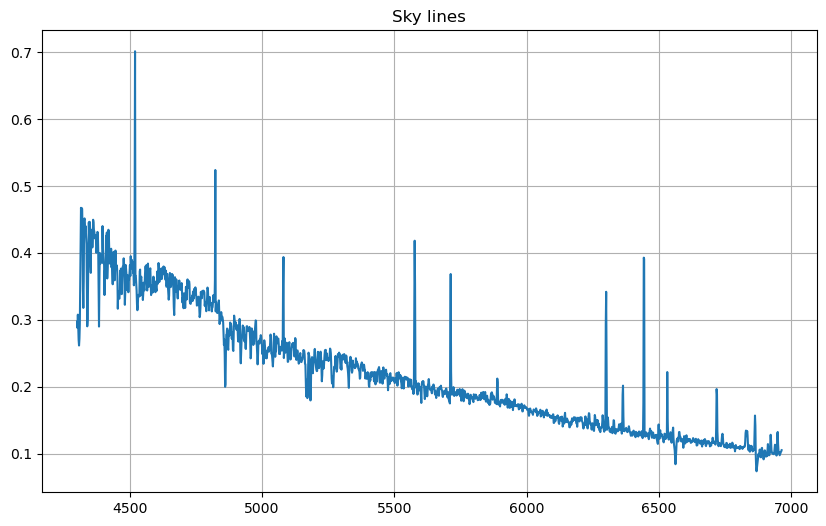

In [86]:
mask_sky = (y > 15)*(y < 25)
image_sky = image_cut2[mask_sky, :]
radial_profile_sky = np.mean(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wavelenghts, radial_profile_sky)
#x_interval = np.arange(4300, 4300+1800*1.48, 250)
#plt.xticks(x_interval)
plt.grid()
plt.title(r'Sky lines')

import plotly.express as px

fig = px.line(x = wavelenghts, y = radial_profile_sky, labels={'x':'wv', 'y':'Flux'}, title = "Sky lines")# x="wv", y="Flux", title="Sky lines")
#fig.update_layout(
#    xaxis=dict(showgrid=False),
#    yaxis=dict(showgrid=False)
#)

fig.show()

## H$\alpha$

[0.00199995 0.00200032 0.00201779 0.00201654 0.00201868 0.00203275
 0.00201366 0.0020099  0.00203024 0.00205202 0.00203898 0.00203963
 0.0020376  0.00202088 0.00204492 0.00207772 0.00209198 0.00213538
 0.00217228 0.00222195 0.00228526 0.00227263 0.00223645 0.00223431
 0.00227714 0.00233891 0.00243793 0.0025702  0.00272596 0.00295238
 0.00321087 0.0034536  0.00376587 0.00418121 0.00487717 0.00576524
 0.00630024 0.00602531 0.00534679 0.00486246 0.00457629 0.00432444
 0.00415814 0.00401824 0.00374189 0.00338401 0.00306796 0.0028266
 0.00268036 0.00262352 0.00260347 0.00260557 0.00261961 0.00266591
 0.00274526 0.00279248 0.00288641 0.00317191 0.00381031 0.00446422
 0.00446514 0.00390629 0.00329925 0.0029124  0.00273268 0.00260608
 0.00251682 0.00248584 0.00246874 0.00246579 0.00251553 0.00255168
 0.00257687 0.0025161  0.00246694 0.00242411 0.0023613  0.00230715
 0.00224925 0.00217891 0.00216434 0.00215001 0.00212812 0.00213713
 0.00213505 0.00209866 0.00210264 0.00207148 0.00208502 0.00206

Text(0.5, 1.0, 'H$\\alpha$')

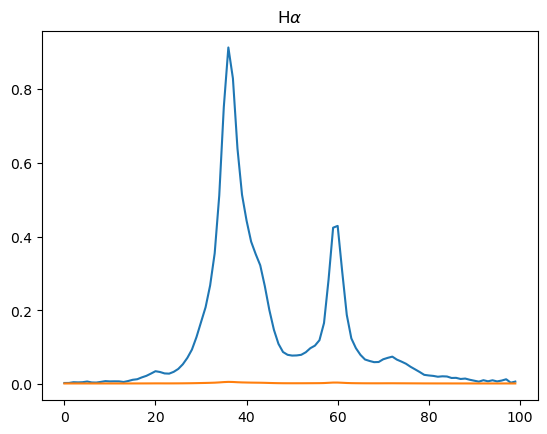

In [7]:
#Ogni punto del flusso è il risultato della media di 20 lunghezze d'onda, otteniamo l'errore come std della media
mask_HA = (wavelenghts > l_HA-10)*(wavelenghts < l_HA+10)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.mean(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))/image_error_HA.shape[1]
print(radial_profile_error_HA)

x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [88]:
np.sqrt(np.sum(image_error_HA[0]**2))/len(image_error_HA[0])
image_error_HA.shape[1]

13

In [89]:
image_error_HA[:, 7]

array([0.00719964, 0.00716636, 0.00713236, 0.00721354, 0.00737467,
       0.00749214, 0.0075564 , 0.00730903, 0.00728604, 0.00769035,
       0.00758607, 0.00747766, 0.00744139, 0.00739624, 0.00749539,
       0.0077408 , 0.00786305, 0.00766336, 0.00761351, 0.00779215,
       0.00789512, 0.00802868, 0.0082304 , 0.00853798, 0.00883493,
       0.00907985, 0.00946892, 0.01010476, 0.01071307, 0.01151189,
       0.01300277, 0.01381353, 0.0147665 , 0.01698969, 0.0206352 ,
       0.02544307, 0.02793511, 0.02587998, 0.02216176, 0.02009732,
       0.01946655, 0.01849345, 0.01779391, 0.01720328, 0.01595465,
       0.01417364, 0.01242753, 0.01135235, 0.0105706 , 0.01016033,
       0.0100691 , 0.01018346, 0.01000953, 0.01022657, 0.01087661,
       0.01123802, 0.01182259, 0.01355989, 0.01698731, 0.02066084,
       0.02059019, 0.01726205, 0.01386188, 0.01178729, 0.01118319,
       0.010574  , 0.00994297, 0.00939923, 0.009142  , 0.00897904,
       0.00946809, 0.00920493, 0.00938193, 0.0092591 , 0.00890

In [90]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 20),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (2, 20),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (2, 10),
    (0.1, 50),
    (50, 70),

    (0, 0.1),
    (2, 10),
    (0.1, 50),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 6.2630239576922815
differential_evolution step 2: f(x)= 3.6486649986703403
differential_evolution step 3: f(x)= 2.5578838308974254
differential_evolution step 4: f(x)= 2.5578838308974254
differential_evolution step 5: f(x)= 2.397895191356553
differential_evolution step 6: f(x)= 2.397895191356553
differential_evolution step 7: f(x)= 2.397895191356553
differential_evolution step 8: f(x)= 1.7859124637962758
differential_evolution step 9: f(x)= 1.513247878886148
differential_evolution step 10: f(x)= 1.513247878886148
differential_evolution step 11: f(x)= 1.3168132019122272
differential_evolution step 12: f(x)= 0.7560820921986346
differential_evolution step 13: f(x)= 0.7560820921986346
differential_evolution step 14: f(x)= 0.7560820921986346
differential_evolution step 15: f(x)= 0.7400798399082702
differential_evolution step 16: f(x)= 0.7400798399082702
differential_evolution step 17: f(x)= 0.7400798399082702
differential_evolution step 18: f(x)= 0.74007

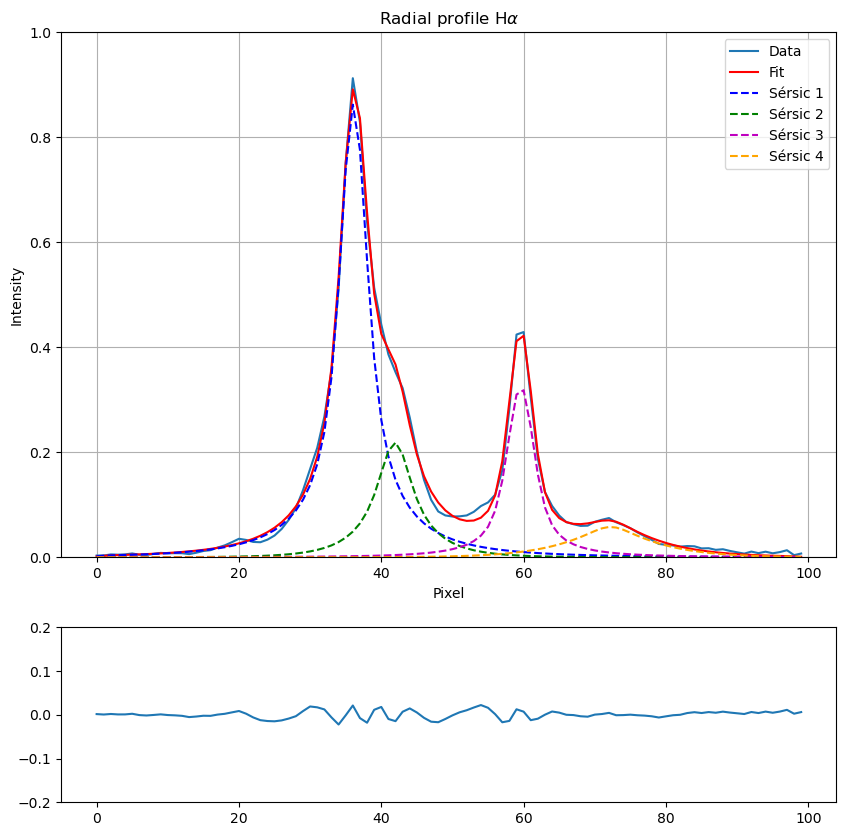

In [91]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

plt.savefig('Radial_profile_Halpha_diff')

In [92]:
params_curve_HA, covariance_HA = curve_fit(model_convolved, x_axes, radial_profile_HA, p0=result.x, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")
for i in range(4):
    I_e, r_e, n, x_0 = params_curve_HA[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

#print(covariance)
print(np.sqrt(np.diag(covariance_HA)))
#print(infodict.fvec**2)
chi2_HA = np.sum((((radial_profile_HA - model_convolved(x_axes, *params_curve_HA)) / radial_profile_error_HA)**2))
dof_HA = len(radial_profile_HA) - len(params_curve_HA)
chi2_reduced_HA = chi2_HA / dof_HA
print(chi2_reduced_HA)

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10712\834272784.py:11: RuntimeWarning:

invalid value encountered in power

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10712\834272784.py:22: RuntimeWarning:

Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.



Optimize parameters with curve fit:
Sérsic 1: I_e=0.0652, r_e=9.3980, n=1.9046, x_0=36.1831
Sérsic 2: I_e=0.0329, r_e=5.8703, n=1.3642, x_0=42.1087
Sérsic 3: I_e=0.0071, r_e=17.2016, n=3.2743, x_0=59.5634
Sérsic 4: I_e=0.0034, r_e=33.3310, n=1.7876, x_0=72.2128
[1.27251554e-02 1.23125001e+00 1.48086576e-01 4.59309065e-02
 1.94651382e-02 2.90053126e+00 4.28397092e-01 1.67572254e-01
 3.99518933e-02 6.70413857e+01 5.76808198e+00 1.38472558e-03
 2.69095275e-03 3.08881293e+01 5.29757657e-01 4.10170554e-01]
7.546305811254809


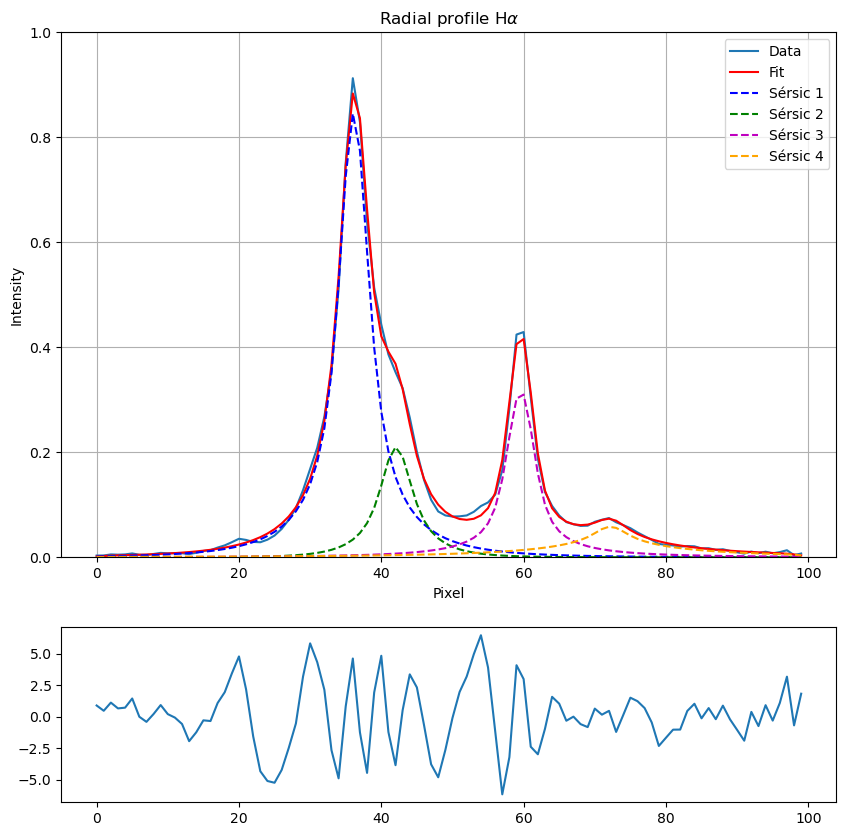

In [93]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_HA)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].plot(x_axes, (radial_profile_HA - y_fit)/radial_profile_error_HA)
#ax[1].set_ylim(-0.1, 0.1)

plt.savefig('Radial_profile_Halpha_curve')

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

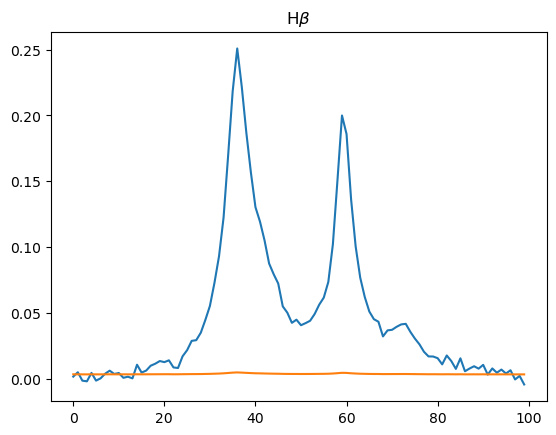

In [94]:
mask_HB = (wavelenghts > l_HB-10)*(wavelenghts < l_HB+10)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.mean(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))/image_error_HB.shape[1]

x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [95]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 20),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (2, 20),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (2, 10),
    (0.1, 50),
    (50, 70),

    (0, 0.1),
    (2, 10),
    (0.1, 50),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 9.325922519604116
differential_evolution step 2: f(x)= 3.662566794459944
differential_evolution step 3: f(x)= 1.4118047689317232
differential_evolution step 4: f(x)= 0.28140436106927447
differential_evolution step 5: f(x)= 0.28140436106927447
differential_evolution step 6: f(x)= 0.28140436106927447
differential_evolution step 7: f(x)= 0.28140436106927447
differential_evolution step 8: f(x)= 0.28140436106927447
differential_evolution step 9: f(x)= 0.28140436106927447
differential_evolution step 10: f(x)= 0.14939875128165034
differential_evolution step 11: f(x)= 0.14939875128165034
differential_evolution step 12: f(x)= 0.14939875128165034
differential_evolution step 13: f(x)= 0.09656774690760325
differential_evolution step 14: f(x)= 0.09656774690760325
differential_evolution step 15: f(x)= 0.09656774690760325
differential_evolution step 16: f(x)= 0.09656774690760325
differential_evolution step 17: f(x)= 0.06992177767771506
differential_evolution step 

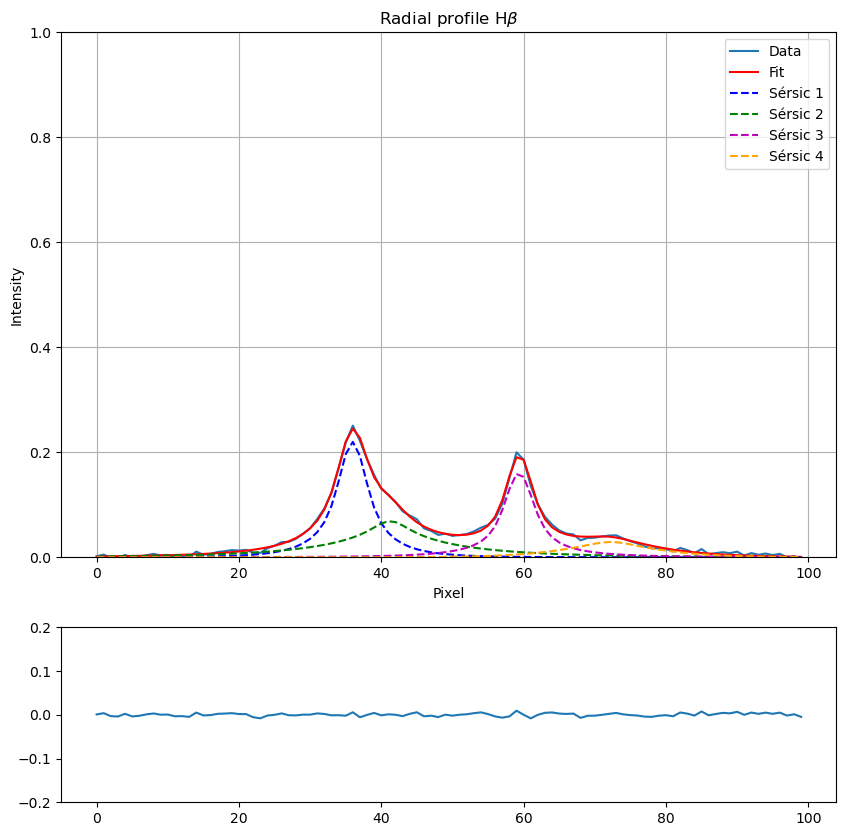

In [96]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HB, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\beta$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0,1)

ax[1].plot(x_axes, radial_profile_HB - y_fit)
ax[1].set_ylim(-0.2, 0.2)
plt.savefig('Radial_profile_Hbeta_kernel')

In [97]:
params_curve_HB, covariance_HB = curve_fit(model_convolved, x_axes, radial_profile_HB, p0=result.x, sigma = radial_profile_error_HB)

print("Optimize parameters with curve fit:")
for i in range(4):
    I_e, r_e, n, x_0 = params_curve_HB[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

#print(covariance)
print(np.sqrt(np.diag(covariance_HB)))
#print(infodict.fvec**2)
chi2_HB = np.sum((((radial_profile_HB - model_convolved(x_axes, *params_curve_HB)) / radial_profile_error_HB)**2))
dof_HB = len(radial_profile_HB) - len(params_curve_HB)
chi2_reduced_HB = chi2_HB / dof_HB
print(chi2_reduced_HB)

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0273, r_e=6.8643, n=1.5014, x_0=35.9537
Sérsic 2: I_e=0.0076, r_e=18.6224, n=1.3672, x_0=41.2646
Sérsic 3: I_e=0.0093, r_e=10.8902, n=2.2445, x_0=59.4149
Sérsic 4: I_e=0.0038, r_e=20.3418, n=1.3156, x_0=72.2166
[7.70496968e-03 1.68552067e+00 2.04171398e-01 7.04087227e-02
 3.93882254e-03 5.27345532e+00 2.64857308e-01 4.71825403e-01
 2.36156538e-02 2.02376311e+01 2.45205919e+00 1.36704120e-02
 2.14940536e-03 8.82402878e+00 3.24136797e-01 4.77638093e-01]
0.8865752316104848


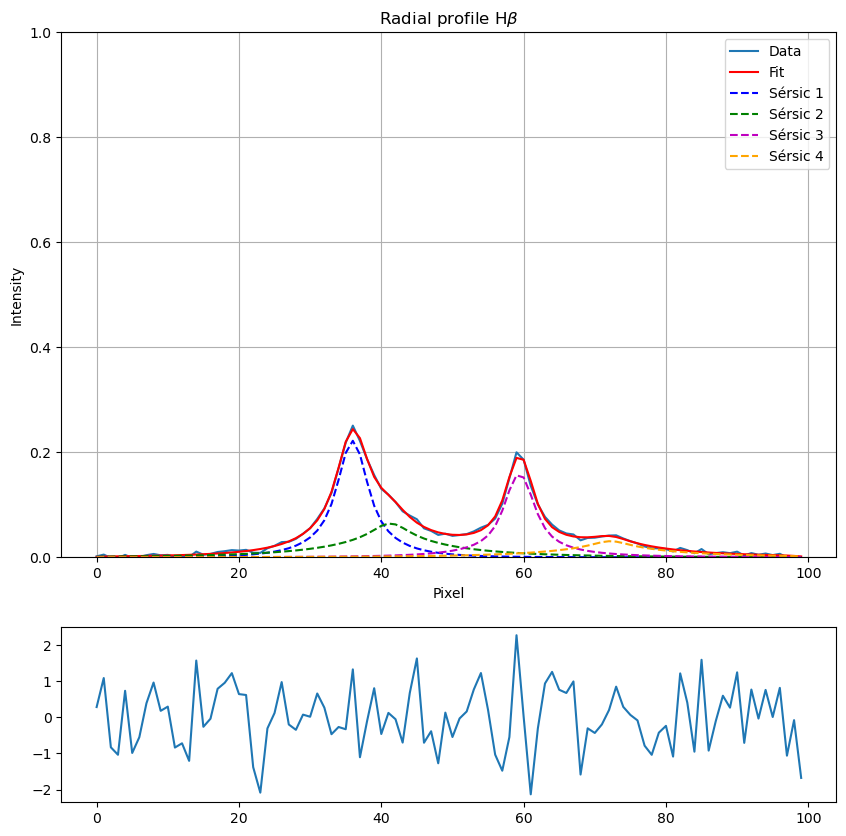

In [98]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_HB)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HB, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\beta$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].plot(x_axes, (radial_profile_HB - y_fit)/radial_profile_error_HB)
#ax[1].set_ylim(-0.1, 0.1)
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

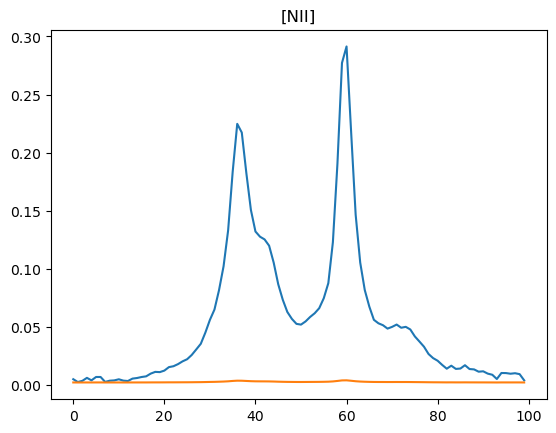

In [8]:
mask_NII = (wavelenghts > l_NII-10)*(wavelenghts < l_NII+10)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.mean(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))/image_error_NII.shape[1]
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [9]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (50, 70),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 0.7448406807044096
differential_evolution step 2: f(x)= 0.7448406807044096
differential_evolution step 3: f(x)= 0.31799903555370007
differential_evolution step 4: f(x)= 0.31799903555370007
differential_evolution step 5: f(x)= 0.2750888374095109
differential_evolution step 6: f(x)= 0.2750888374095109
differential_evolution step 7: f(x)= 0.23400915724868526
differential_evolution step 8: f(x)= 0.1458577154664068
differential_evolution step 9: f(x)= 0.1458577154664068
differential_evolution step 10: f(x)= 0.1458577154664068
differential_evolution step 11: f(x)= 0.11438056295359031
differential_evolution step 12: f(x)= 0.1117411397304309
differential_evolution step 13: f(x)= 0.09358312607057055
differential_evolution step 14: f(x)= 0.09358312607057055
differential_evolution step 15: f(x)= 0.09358312607057055
differential_evolution step 16: f(x)= 0.09358312607057055
differential_evolution step 17: f(x)= 0.06780576669425153
differential_evolution step 18:

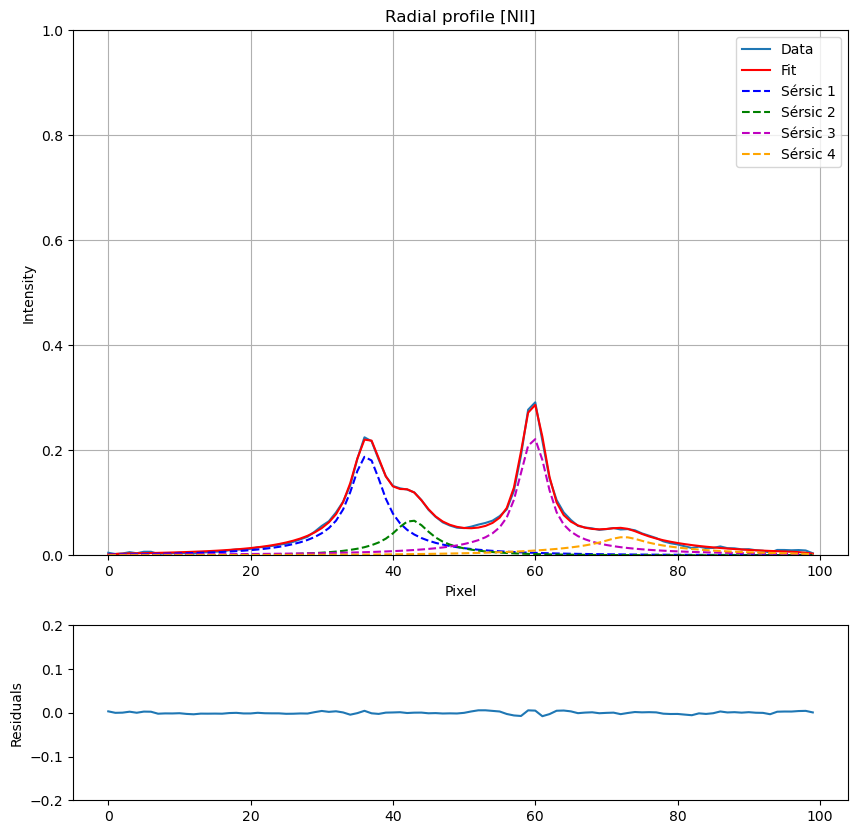

In [10]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_NII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [NII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].plot(x_axes, radial_profile_NII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')
plt.savefig('Radial_profile_NII_kernel')

In [11]:
params_curve_NII, covariance_NII = curve_fit(model_convolved, x_axes, radial_profile_NII, p0=result.x, sigma = radial_profile_error_NII)

print("Optimize parameters with curve fit:")
for i in range(4):
    I_e, r_e, n, x_0 = params_curve_NII[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

#print(covariance)
print(np.sqrt(np.diag(covariance_NII)))
#print(infodict.fvec**2)
chi2_NII = np.sum((((radial_profile_NII - model_convolved(x_axes, *params_curve_NII)) / radial_profile_error_NII)**2))
dof_NII = len(radial_profile_NII) - len(params_curve_NII)
chi2_reduced_NII = chi2_NII / dof_NII
print(chi2_reduced_NII)

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0102, r_e=15.0576, n=2.1118, x_0=36.3113
Sérsic 2: I_e=0.0082, r_e=10.3768, n=1.4759, x_0=42.4902
Sérsic 3: I_e=0.0017, r_e=50.3747, n=3.8675, x_0=59.6624
Sérsic 4: I_e=0.0035, r_e=23.5624, n=1.4343, x_0=72.4077
[4.43345092e-03 5.76899343e+00 3.02903170e-01 5.54041039e-02
 5.82234474e-03 7.05935152e+00 4.84325541e-01 1.71670746e-01
 4.26073227e-03 9.75409749e+01 2.30420244e+00 1.47827990e-04
 1.63381350e-03 1.42812426e+01 3.24642697e-01 3.10669837e-01]
1.3697879478515522


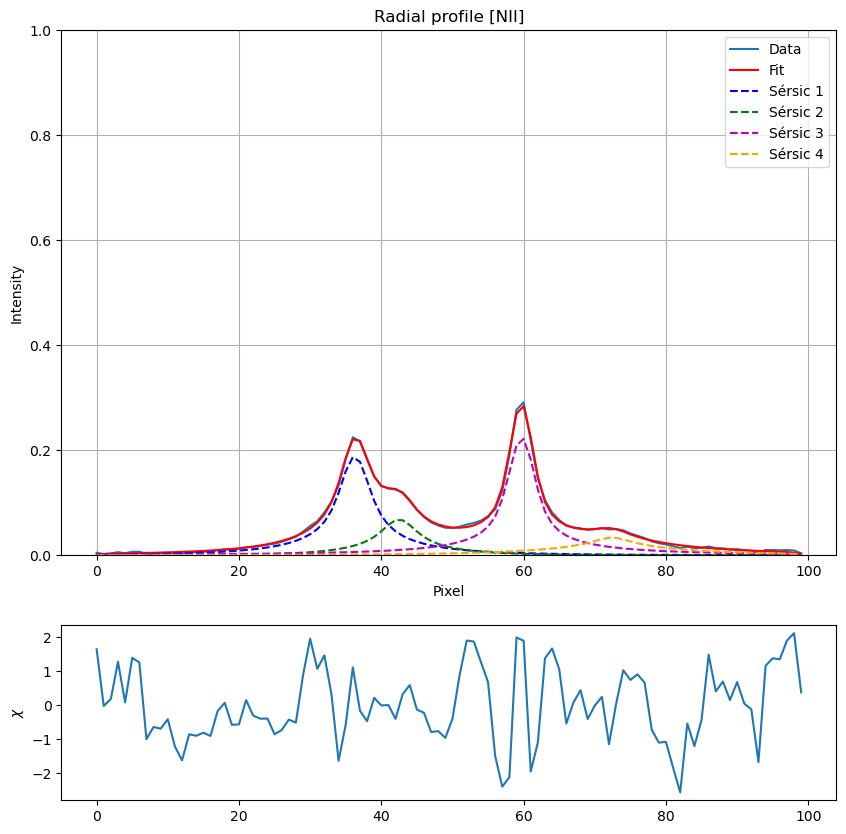

In [16]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_NII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_NII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [NII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].plot(x_axes, (radial_profile_NII - y_fit)/radial_profile_error_NII)
#ax[1].set_ylim(-0.1, 0.1)
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

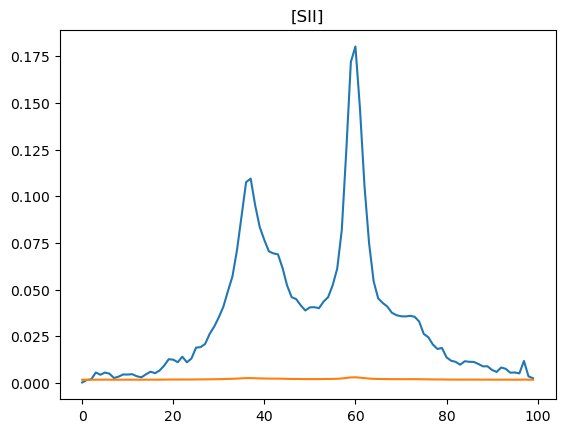

In [17]:
mask_SII = (wavelenghts > l_SII-10)*(wavelenghts < l_SII+10)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.mean(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))/image_error_SII.shape[1]
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [18]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 20),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (2, 20),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (2, 10),
    (0.1, 50),
    (50, 70),

    (0, 0.1),
    (2, 10),
    (0.1, 50),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 5.328656731990475
differential_evolution step 2: f(x)= 4.928461221963613
differential_evolution step 3: f(x)= 4.928461221963613
differential_evolution step 4: f(x)= 0.2379748986356419
differential_evolution step 5: f(x)= 0.2379748986356419
differential_evolution step 6: f(x)= 0.20449053618184895
differential_evolution step 7: f(x)= 0.20449053618184895
differential_evolution step 8: f(x)= 0.20449053618184895
differential_evolution step 9: f(x)= 0.20449053618184895
differential_evolution step 10: f(x)= 0.15769979321354932
differential_evolution step 11: f(x)= 0.08541189172795725
differential_evolution step 12: f(x)= 0.08541189172795725
differential_evolution step 13: f(x)= 0.08541189172795725
differential_evolution step 14: f(x)= 0.08541189172795725
differential_evolution step 15: f(x)= 0.08541189172795725
differential_evolution step 16: f(x)= 0.08541189172795725
differential_evolution step 17: f(x)= 0.08541189172795725
differential_evolution step 18:

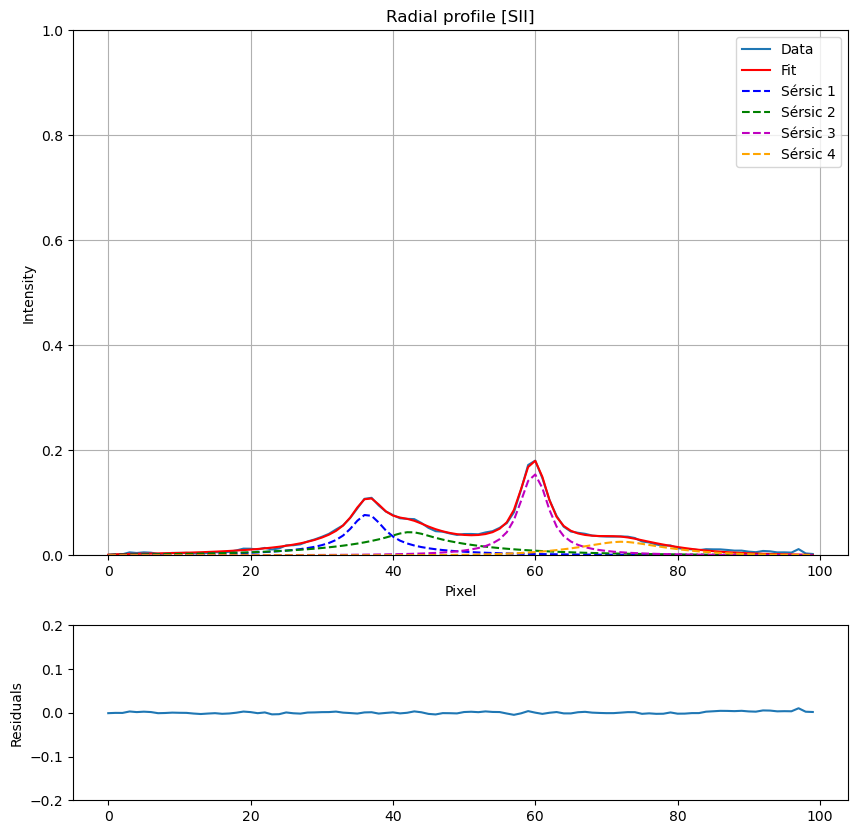

In [20]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_SII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [SII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0,1)

ax[1].plot(x_axes, radial_profile_SII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')
plt.savefig('Radial_profile_SII_diff')

In [21]:
params_curve_SII, covariance_SII = curve_fit(model_convolved, x_axes, radial_profile_SII, p0=result.x, sigma = radial_profile_error_SII)

print("Optimize parameters with curve fit:")
for i in range(4):
    I_e, r_e, n, x_0 = params_curve_SII[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

#print(covariance)
print(np.sqrt(np.diag(covariance_SII)))
#print(infodict.fvec**2)
chi2_SII = np.sum((((radial_profile_SII - model_convolved(x_axes, *params_curve_SII)) / radial_profile_error_SII)**2))
dof_SII = len(radial_profile_SII) - len(params_curve_SII)
chi2_reduced_SII = chi2_SII / dof_SII
print(chi2_reduced_SII)

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0059, r_e=15.5030, n=1.8316, x_0=36.4141
Sérsic 2: I_e=0.0048, r_e=18.2843, n=1.3008, x_0=42.5264
Sérsic 3: I_e=0.0048, r_e=15.6289, n=2.7192, x_0=59.7614
Sérsic 4: I_e=0.0017, r_e=42.9942, n=1.6796, x_0=71.8311
[5.98034435e-03 1.82422479e+01 6.72778927e-01 9.95019851e-02
 3.40144523e-03 2.70708214e+01 5.18251111e-01 4.12129722e-01
 2.01131848e-02 4.99593774e+01 3.81368866e+00 2.71834908e-03
 1.24352863e-03 2.00340384e+01 3.66218588e-01 3.74488788e-01]
0.9747996796670002


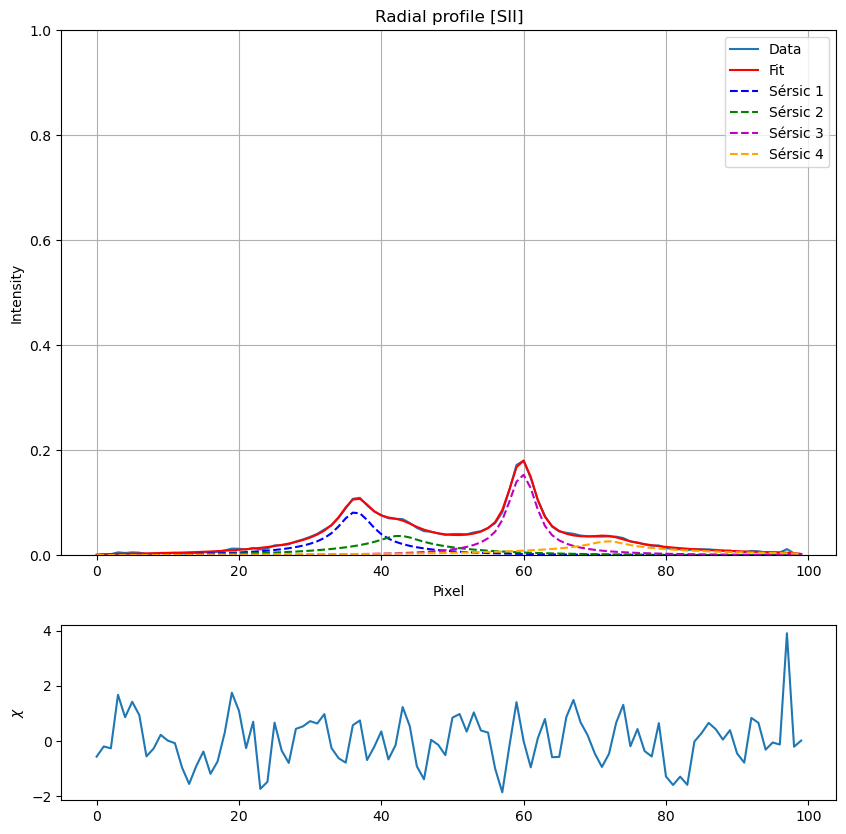

In [24]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_SII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_SII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [SII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].plot(x_axes, (radial_profile_SII - y_fit)/radial_profile_error_SII)
#ax[1].set_ylim(-0.1, 0.1)
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

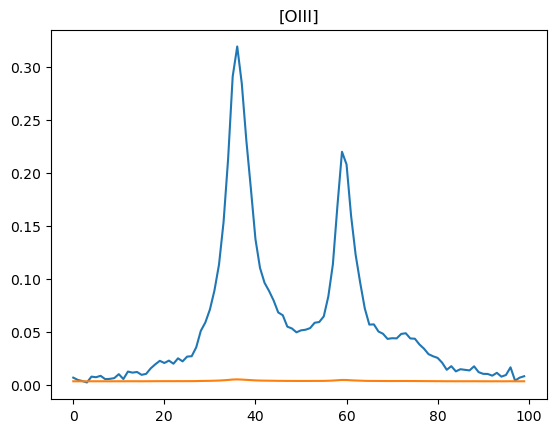

In [25]:
mask_OIII = (wavelenghts > l_OIII-10)*(wavelenghts < l_OIII+10)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.mean(image_OIII, axis = 1) 
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))/image_error_OIII.shape[1]
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [26]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 20),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (2, 20),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (2, 10),
    (0.1, 50),
    (50, 70),

    (0, 0.1),
    (2, 10),
    (0.1, 50),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 0.596313860001073
differential_evolution step 2: f(x)= 0.596313860001073
differential_evolution step 3: f(x)= 0.596313860001073
differential_evolution step 4: f(x)= 0.5900032357869672
differential_evolution step 5: f(x)= 0.5900032357869672
differential_evolution step 6: f(x)= 0.5684609893283504
differential_evolution step 7: f(x)= 0.5043527906312281
differential_evolution step 8: f(x)= 0.20322965615528604
differential_evolution step 9: f(x)= 0.20322965615528604
differential_evolution step 10: f(x)= 0.20322965615528604
differential_evolution step 11: f(x)= 0.20322965615528604
differential_evolution step 12: f(x)= 0.1574114581039631
differential_evolution step 13: f(x)= 0.11143411547640134
differential_evolution step 14: f(x)= 0.11143411547640134
differential_evolution step 15: f(x)= 0.09155681707555352
differential_evolution step 16: f(x)= 0.09155681707555352
differential_evolution step 17: f(x)= 0.09155681707555352
differential_evolution step 18: f(

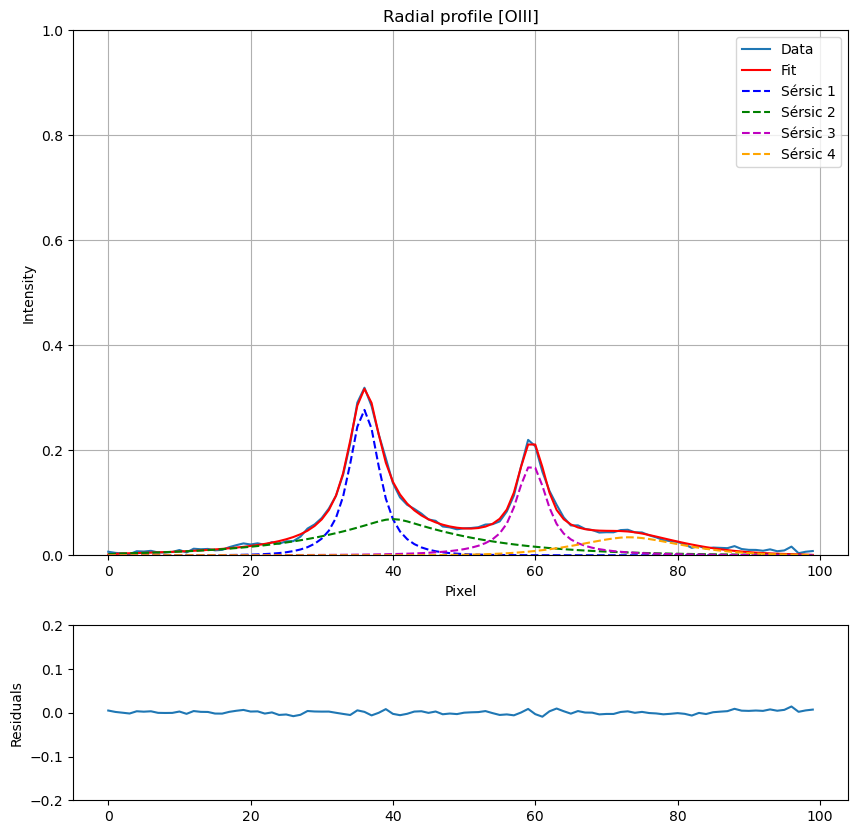

In [27]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_OIII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [OIII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].plot(x_axes, radial_profile_OIII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')

plt.savefig('Radial_profile_OIII_kernel')

In [28]:
params_curve_OIII, covariance_OIII = curve_fit(model_convolved, x_axes, radial_profile_OIII, p0=result.x, sigma = radial_profile_error_OIII)

print("Optimize parameters with curve fit:")
for i in range(4):
    I_e, r_e, n, x_0 = params_curve_OIII[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

#print(covariance)
print(np.sqrt(np.diag(covariance_OIII)))
#print(infodict.fvec**2)
chi2_OIII = np.sum((((radial_profile_OIII - model_convolved(x_axes, *params_curve_OIII)) / radial_profile_error_OIII)**2))
dof_OIII = len(radial_profile_OIII) - len(params_curve_OIII)
chi2_reduced_OIII = chi2_OIII / dof_OIII
print(chi2_reduced_OIII)

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0419, r_e=6.1539, n=1.4312, x_0=36.0381
Sérsic 2: I_e=0.0045, r_e=45.8958, n=1.3664, x_0=42.6127
Sérsic 3: I_e=0.0070, r_e=14.0957, n=2.5178, x_0=59.5139
Sérsic 4: I_e=0.0032, r_e=24.7955, n=1.4388, x_0=73.0726
[7.70804111e-03 1.07680381e+00 1.35619193e-01 4.20539091e-02
 4.85560746e-03 3.01312755e+01 4.92547773e-01 9.15285290e-01
 2.55321309e-02 3.84582143e+01 3.36144496e+00 7.20280870e-03
 2.01128779e-03 1.72486133e+01 3.88874144e-01 4.95948143e-01]
1.059564104239603


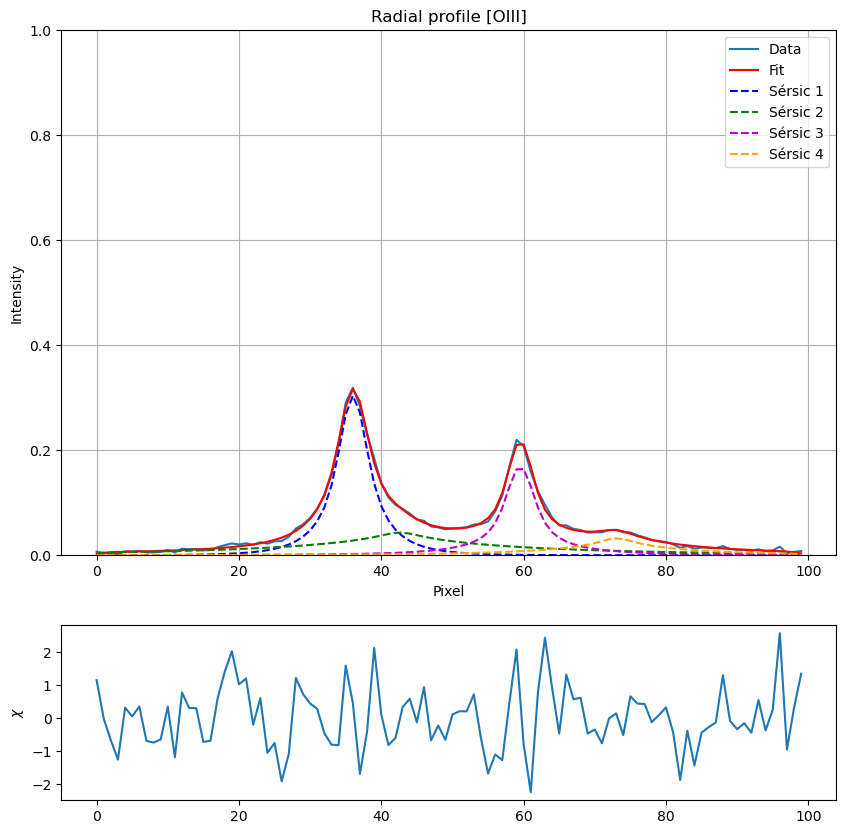

In [31]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_OIII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_OIII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [OIII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].plot(x_axes, (radial_profile_OIII - y_fit)/radial_profile_error_OIII)
#ax[1].set_ylim(-0.1, 0.1)
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_OIII_curve')

In [ ]:
radial_profile_OIII - y_fit

In [ ]:
radial_profile_error_OIII